In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pypalettes as pyp
from scipy.signal import find_peaks as peak_widths
from dataclasses import dataclass
from typing import Tuple
from scipy.stats import median_abs_deviation
from ca_imaging import process_flourescent_signal, find_peaks, measure_peak_properties
from ca_imaging.peak_properties import calculate_fwhm

ccmap = pyp.load_cmap("GeorgiaOKeeffe", cmap_type="continuous")
dcmap = pyp.load_cmap("GeorgiaOKeeffe", cmap_type="discrete")
from pathlib import Path
from tqdm import tqdm

# Define output folder

In [2]:
output_folder = Path("/workspaces/melanopsin-paper/python/output")
output_folder.mkdir(exist_ok=True)
output_folder_qc = output_folder / "quality_control" # Folder for quality control of calculations
output_folder_qc.mkdir(exist_ok=True)

# Import the data

In [3]:
calcium_data_file = "/workspaces/melanopsin-paper/python/data/Fura2_export.csv"
df = pd.read_csv(calcium_data_file).set_index('Time (sec)').rename(columns=lambda x: x.strip().replace("\"", ""), inplace=False)

# Process the flourescent raw signals to DF/F0

In [4]:
calcium_signals = {}

for cell_name in df.columns[:-6]:
    calcium_signals[cell_name] = process_flourescent_signal(
        f=df[cell_name].values,
        times=df.index.values,
    )

# Find the peaks in the DF_F0 signal

In [5]:
calcium_peaks = {}
for cell_name in calcium_signals:
    calcium_peaks[cell_name] = {}
    peaks = find_peaks(
        calcium_signals[cell_name].DF_F0, 
        calcium_signals[cell_name].times,
        distance_t=25,
        window_size_t=90,
        min_prominence=0.03 if cell_name in ["R27 R1", "R26 R1"] else None
    )
    calcium_peaks[cell_name]["peaks"] = peaks
    calcium_peaks[cell_name]["peak_properties"] = measure_peak_properties(calcium_signals[cell_name].DF_F0, calcium_signals[cell_name].times, peaks)

# Calculate when led is on 5s

In [6]:
led_5s = df["LED 5 s"] == 1
led_5s_times = df.index[df["LED 5 s"] == 1]

# Find calcium peaks close to when the LED light is on

In [7]:
for cell_name in calcium_peaks:
    peaks = []
    peak_properties = []
    for peak, properties in zip(calcium_peaks[cell_name]["peaks"], calcium_peaks[cell_name]["peak_properties"]):
        time_from_led = peak.time - led_5s_times.values
        time_from_led = time_from_led[time_from_led > -5]
        if len(time_from_led) > 0 and time_from_led.min() <  30:
            peaks.append(peak)
            peak_properties.append(properties)
    calcium_peaks[cell_name]["peaks"] = peaks
    calcium_peaks[cell_name]["peak_properties"] = peak_properties

# Plot df_f0 and peak detections for all cells for visual quality control

In [12]:
mpl.use('Agg')

(output_folder_qc / "peak_detections").mkdir(parents=True, exist_ok=True)

for cell_name in tqdm(calcium_signals.keys()):
    fig, axes = plt.subplots(1,2, figsize=(14,6), width_ratios=[3,1.5])


    signals = calcium_signals[cell_name]
    peaks = calcium_peaks[cell_name]

    axes[0].plot(signals.times, signals.DF_F0, c=dcmap(0))

    axes[0].vlines(led_5s_times.values, ymin=0, ymax=signals.DF_F0.max())

    for peak, properties in zip(peaks["peaks"], peaks["peak_properties"]):
        axes[0].scatter(peak.time, peak.value, c="k")
        axes[1].plot(peak.y, c="k")

    axes[0].set_ylabel(fr"$\Delta f / f_0$ (-)", fontsize=16)
    axes[0].set_xlabel(fr"Time (s)", fontsize=16)
    axes[1].set_xlabel(fr"Time (s)", fontsize=16)

    axes[0].set_title(f"{cell_name}")
    axes[1].set_title(f"Peaks")

    f = fig.savefig(output_folder_qc / "peak_detections" / f"df_f0_{cell_name}.png")
    plt.close(fig)

100%|██████████| 27/27 [00:04<00:00,  6.20it/s]


# Quality check fwhm

In [13]:
mpl.use('Agg')

for cell_name in tqdm(calcium_signals.keys()):

    peaks = calcium_peaks[cell_name]["peaks"]
    peak_properties = calcium_peaks[cell_name]["peak_properties"]

    t_0 = 0

    for n, (peak, properties) in enumerate(zip(peaks, peak_properties)):

        fig = plt.figure(figsize=(6,6))
        ax = plt.axes()

        try:
            ax.vlines([properties.fwhm_left_it, properties.fwhm_right_it], ymin=0, ymax=peak.y.max())
            ax.plot(peak.times, peak.y, c=dcmap(0))
            ax.text(peak.times[peak.peak_index_local], peak.value / 2, f"fwhm = {properties.fwhm:.2f} s")
            t_0 += peak.times[-1] - peak.times[0] + 5
        except:
            pass
        folder = output_folder_qc / "fwhm" / cell_name
        folder.mkdir(parents=True, exist_ok=True)
        f = fig.savefig(folder / f"{cell_name}_{n}.png")
        plt.close(fig)

# Quality check decay and rise time

In [14]:
mpl.use('Agg')

for cell_name in tqdm(list(calcium_signals.keys())):

    peaks = calcium_peaks[cell_name]["peaks"]
    peak_properties = calcium_peaks[cell_name]["peak_properties"]

    for n, (peak, properties) in enumerate(zip(peaks, peak_properties)):

        fig = plt.figure(figsize=(12,6))
        ax = plt.axes()

        try:
            ax.vlines([properties.rise_time_left_it, properties.rise_time_right_it], ymin=0, ymax=peak.y.max())
            ax.vlines([properties.decay_time_left_it, properties.decay_time_right_it], ymin=0, ymax=peak.y.max())
            ax.plot(peak.times, peak.y, c=dcmap(0))
            ax.text(properties.rise_time_left_it, peak.value*1.1, fr"$\tau_r = {properties.rise_time:.2f}$ s")
            ax.text(properties.decay_time_right_it, peak.value*1.1, fr"$\tau_d = {properties.decay_time:.2f}$ s")
            ax.set_ylabel(fr"$\Delta f / f_0$ (-)", fontsize=16)
            ax.set_xlabel(fr"Time (s)", fontsize=16)

            t_0 += peak.times[-1] - peak.times[0] + 5
        except:
            pass
        folder = output_folder_qc / "rise_decay_time" / cell_name
        folder.mkdir(parents=True, exist_ok=True)
        fig.savefig(folder / f"{cell_name}_{n}.png")
        plt.close(fig)

100%|██████████| 27/27 [00:23<00:00,  1.15it/s]


# Quality check auc

In [15]:
mpl.use('Agg')

for cell_name in tqdm(list(calcium_signals.keys())):

    peaks = calcium_peaks[cell_name]["peaks"]
    peak_properties = calcium_peaks[cell_name]["peak_properties"]

    for n, (peak, properties) in enumerate(zip(peaks, peak_properties)):

        fig = plt.figure(figsize=(12,6))
        ax = plt.axes()

        try:
            ax.plot(peak.times, peak.y, c=dcmap(0))
            auc_indexes = (peak.times >= properties.auc_left_it) & (peak.times <= properties.auc_right_it)
            ax.fill_between(peak.times[auc_indexes], peak.y[auc_indexes], 0)
            ax.text(peak.times[peak.peak_index_local], peak.value/2, fr"$auc = {properties.auc:.2f}$")
            ax.set_ylabel(fr"$\Delta f / f_0$ (-)", fontsize=16)
            ax.set_xlabel(fr"Time (s)", fontsize=16)

        except:
            pass
        folder = output_folder_qc / "auc" / cell_name
        folder.mkdir(parents=True, exist_ok=True)

        fig.savefig(folder / f"fwhm_{cell_name}_{n}.png")
        plt.close(fig)

100%|██████████| 27/27 [00:19<00:00,  1.39it/s]


# Filter data to only include the region with the 8 mHz stimulation

In [8]:
time_min = 1050
time_max = 2300

led_5s_times = led_5s_times[(led_5s_times > time_min) & (led_5s_times < time_max)]

for cell_name in calcium_signals:
    calcium_signals[cell_name] = calcium_signals[cell_name][(calcium_signals[cell_name].times > time_min) & (calcium_signals[cell_name].times < time_max)]

    peaks_to_be_kept = []
    for n in range(len(calcium_peaks[cell_name]["peaks"])):
        if (
            (calcium_peaks[cell_name]["peaks"][n].time > time_min)
            and (calcium_peaks[cell_name]["peaks"][n].time < time_max)
        ):
            peaks_to_be_kept.append(n)

    calcium_peaks[cell_name]["peaks"] = [calcium_peaks[cell_name]["peaks"][p] for p in peaks_to_be_kept]
    calcium_peaks[cell_name]["peak_properties"] = [calcium_peaks[cell_name]["peak_properties"][p] for p in peaks_to_be_kept]

# Calculate response rates

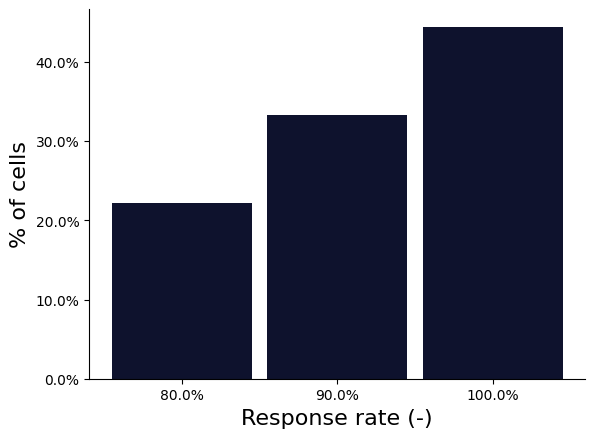

In [9]:
%matplotlib inline
from matplotlib.ticker import PercentFormatter
fig = plt.figure()
ax = plt.axes()

n_stimulations = len(led_5s_times)

response_rates = []

for cell_name in calcium_signals:
    n_peaks = len(calcium_peaks[cell_name]["peaks"])

    response_rates.append(n_peaks / n_stimulations * 100)

unique_response_rates, counts = np.unique(response_rates, return_counts=True)



boxprops = dict(linestyle='-', linewidth=3, color=dcmap(0))
flierprops = dict(marker='o', markerfacecolor=dcmap(3), markersize=8, linewidth=4,
                  markeredgecolor="w")

medianlineprops = dict(linewidth=2.5, color=dcmap(3))

ax.bar(unique_response_rates,counts / counts.sum(), width=9, color=dcmap(0))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xticks(unique_response_rates)
ax.xaxis.set_major_formatter(PercentFormatter(100))

ax.set_ylabel("% of cells", fontsize=16)
ax.set_xlabel("Response rate (-)", fontsize=16)
ax.spines[["top", "right"]].set_visible(False)
(output_folder/ "results").mkdir(parents=True, exist_ok=True)
fig.savefig(output_folder/ "results" / "response_rate.png")
fig.savefig(output_folder/ "results" / "response_rate.svg")

# Plot DF / F0

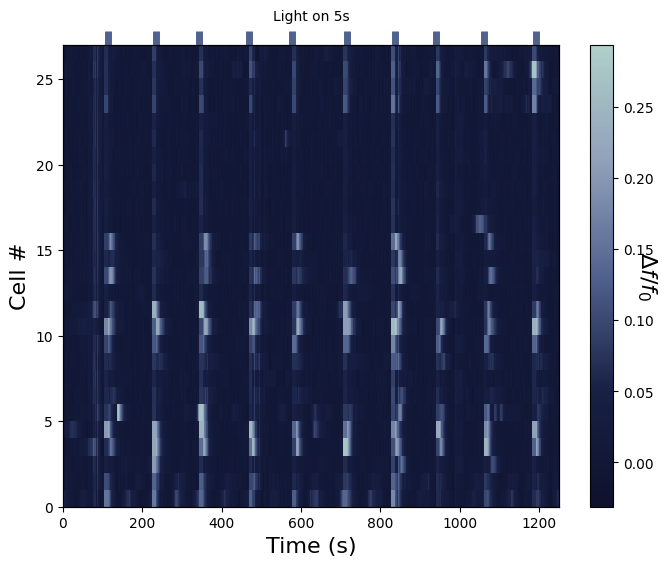

In [10]:
from matplotlib.patches import Rectangle
fig = plt.figure(figsize=(8,6))
ax = plt.axes()
ax2 = ax.twiny()

df_f0 = np.array([calcium_signals[cell_name].DF_F0 for cell_name in calcium_signals])
times = calcium_signals[cell_name].times.copy()

max_df_f0 = df_f0.max()
min_df_f0 = df_f0.min()

for col in range(df_f0.shape[1]):#range(df_f0.shape[1]):
    df_f0_col = df_f0[:,col]
    t_min = 0 if col == 0  else times[col-1] - time_min
    t_max = times[col] - time_min
    im = ax.imshow(df_f0_col[:, np.newaxis], cmap=ccmap, extent=(t_min+0.0001,t_max,0, df_f0.shape[0]), vmin=min_df_f0, vmax=max_df_f0, interpolation="none")

ax2.set_xticks(led_5s_times.values - time_min, ["" for l in led_5s_times.values])
ax2.tick_params(which='major', width=5.00, length=10, color=dcmap(2))
cbar = fig.colorbar(im)
cbar.set_label(r'$\Delta f/f_0$', rotation=-90, fontsize=16)

ax.set_xlim([0, time_max - time_min])
ax.set_ylim([0,len(calcium_signals)])
ax.set_xlabel("Time (s)", fontsize=16)
ax.set_ylabel("Cell #", fontsize=16)
ax.set_aspect("auto")
ax2.set_xlabel("Light on 5s")
ax2.set_xlim(ax.get_xlim())


fig.savefig(output_folder / "results" / "df_f0_heatmap.png")
fig.savefig(output_folder / "results" / "df_f0_heatmap.svg")

# Back to baseline per cell

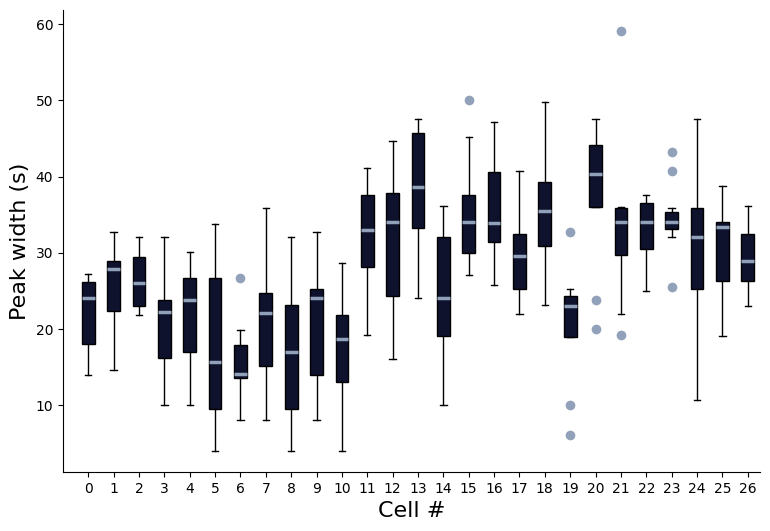

In [11]:
fig = plt.figure(figsize=(9,6))
ax = plt.axes()

cell_names = []

back_to_baseline_time = {}
for cell_name in calcium_signals:
    back_to_baseline_time[cell_name] = [] 
    for led_t in led_5s_times.values:
        for p, pp in zip(calcium_peaks[cell_name]["peaks"], calcium_peaks[cell_name]["peak_properties"]):
            if (p.time - led_t) < 30 and ((p.time - led_t) > -5):
                try:
                    back_to_baseline_time[cell_name].append(pp.decay_time_right_it - led_t)
                    break
                except:
                    pass
        else:
            back_to_baseline_time[cell_name].append(None)

boxprops = dict(linestyle='-', linewidth=3, color=dcmap(0))
flierprops = dict(marker='o', markerfacecolor=dcmap(3), markersize=8, linewidth=4,
                  markeredgecolor="w")

medianlineprops = dict(linewidth=2.5, color=dcmap(3))

for n, cell_name in enumerate(back_to_baseline_time):
    # s = ax.scatter(2*n + 0*(np.arange(len(led_5s_times)) - len(led_5s_times) // 2) // len(led_5s_times) / 2, back_to_baseline_time[cell_name], c=[dcmap(0)])
    bplot_r = ax.boxplot([t for t in back_to_baseline_time[cell_name] if t is not None], positions=[2*n], widths=[1], patch_artist=True, flierprops=flierprops, medianprops=medianlineprops)

    for patch in bplot_r['boxes']:
        patch.set_facecolor(dcmap(0))

t = ax.set_xticks(np.arange(n+1)*2, np.arange(n+1))
ax.spines[["right", "top"]].set_visible(False)
ax.set_xlim([-2, 27*2-1])

ax.set_ylabel("Peak width (s)", fontsize=16)
ax.set_xlabel("Cell #", fontsize=16)

fig.savefig(output_folder / "results" / "peak_widths.png")
fig.savefig(output_folder / "results" / "peak_widths.svg")
